# **Imports and Loading Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, learning_curve, train_test_split
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import loguniform

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
df = pd.read_csv("train_data.csv")
df_test = pd.read_csv("test_data.csv")

## **Some Initial Insights**

In [4]:
df.head()

,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   881 non-null    int64  
 1   Company              881 non-null    object 
 2   Product              881 non-null    object 
 3   TypeName             881 non-null    object 
 4   Inches               881 non-null    float64
 5   ScreenResolution     881 non-null    object 
 6   CPU_Company          881 non-null    object 
 7   CPU_Type             881 non-null    object 
 8   CPU_Frequency (GHz)  881 non-null    float64
 9   RAM (GB)             881 non-null    int64  
 10  Memory               881 non-null    object 
 11  GPU_Company          881 non-null    object 
 12  GPU_Type             881 non-null    object 
 13  OpSys                881 non-null    object 
 14  Weight (kg)          881 non-null    float64
 15  Price (Euro)         881 non-null    flo

In [6]:
df.shape

(881, 16)

In [7]:
df.describe()

,id,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,441.00000,15.085017,2.281839,8.522134,2.049714,1110.183235
std,254.46709,1.396360,0.527334,4.921176,0.657077,711.526332
min,1.00000,10.100000,0.900000,2.000000,0.690000,191.900000
25%,221.00000,14.000000,1.800000,4.000000,1.580000,589.000000
50%,441.00000,15.600000,2.500000,8.000000,2.040000,945.000000
75%,661.00000,15.600000,2.700000,8.000000,2.300000,1426.660000
max,881.00000,18.400000,3.600000,32.000000,4.700000,6099.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

id                     0
Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

In [10]:
df.drop(columns=['id'], inplace=True)

In [11]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


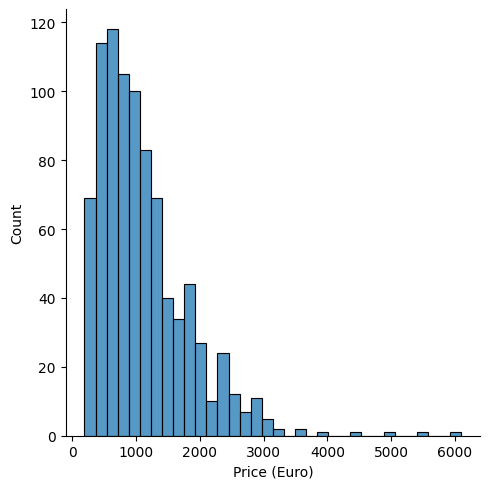

In [12]:
sns.displot(df['Price (Euro)'])

<Axes: xlabel='Company'>

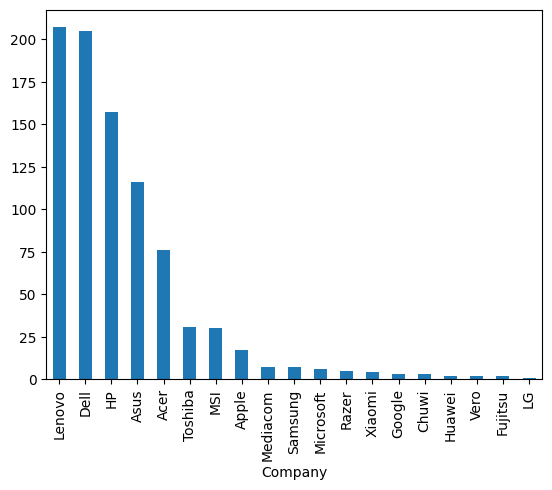

In [13]:
df['Company'].value_counts().plot(kind='bar')

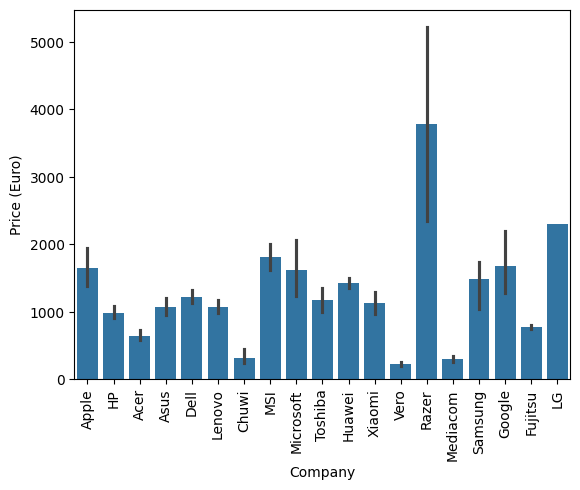

In [14]:
sns.barplot(x=df['Company'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName'>

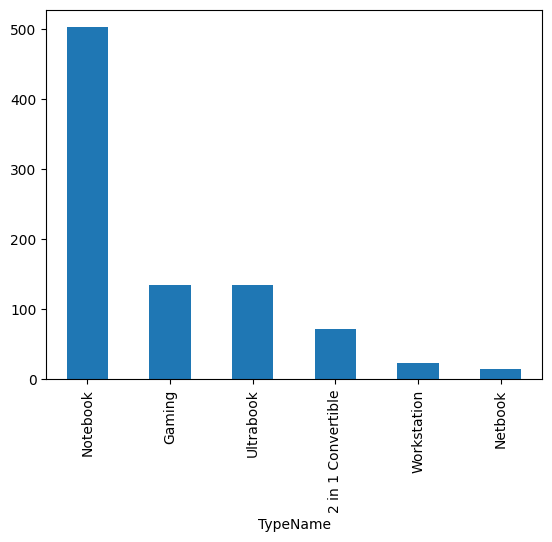

In [15]:
df['TypeName'].value_counts().plot(kind='bar')

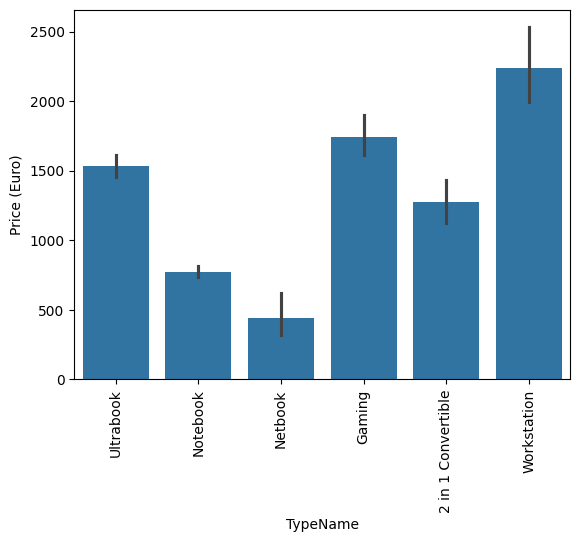

In [16]:
sns.barplot(x=df['TypeName'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

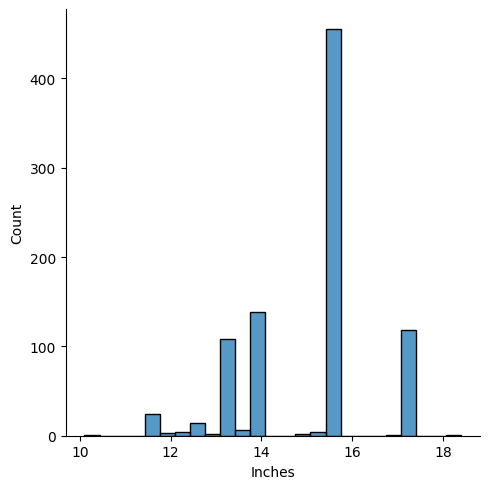

In [17]:
sns.displot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price (Euro)'>

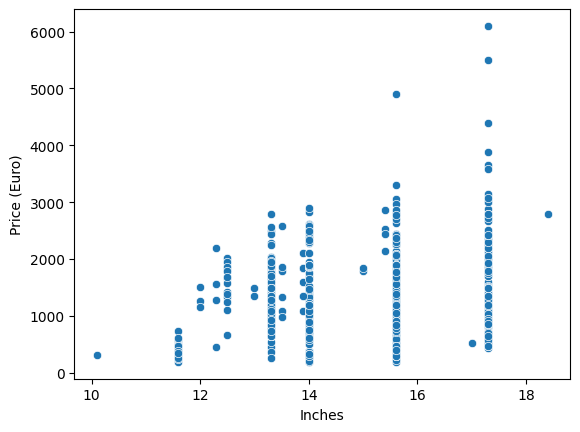

In [18]:
sns.scatterplot(x=df['Inches'],y=df['Price (Euro)'])

# **Feature Engineering**

In [19]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df_test['Touchscreen'] = df_test['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [20]:
df.head(20)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00,0
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97,0
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00,0
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00,0


<Axes: xlabel='Touchscreen'>

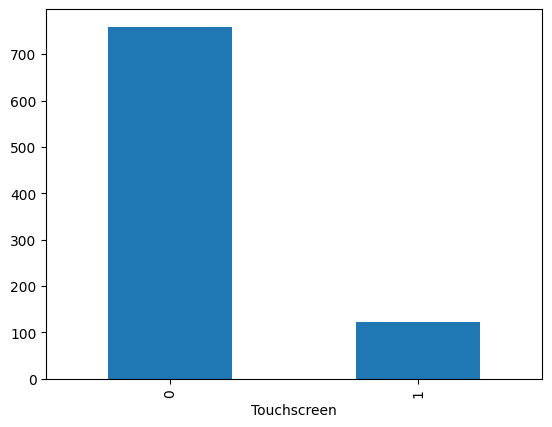

In [21]:
df['Touchscreen'].value_counts().plot(kind='bar')

<Axes: xlabel='Touchscreen', ylabel='Price (Euro)'>

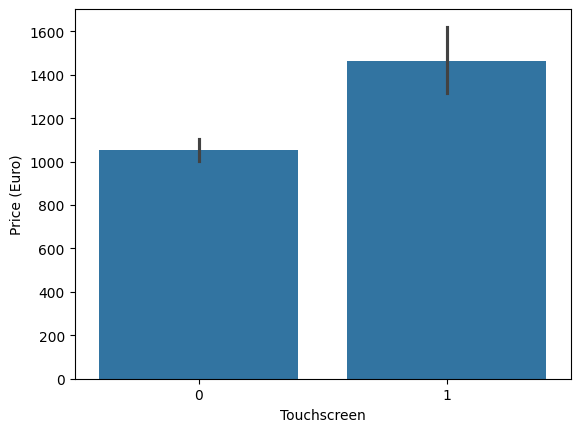

In [22]:
sns.barplot(x=df['Touchscreen'],y=df['Price (Euro)'])

In [23]:
df['Ips'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df_test['Ips'] = df_test['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [24]:
df.head(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00,0,0
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97,0,1
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0,0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00,0,0
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00,0,1


<Axes: xlabel='Ips'>

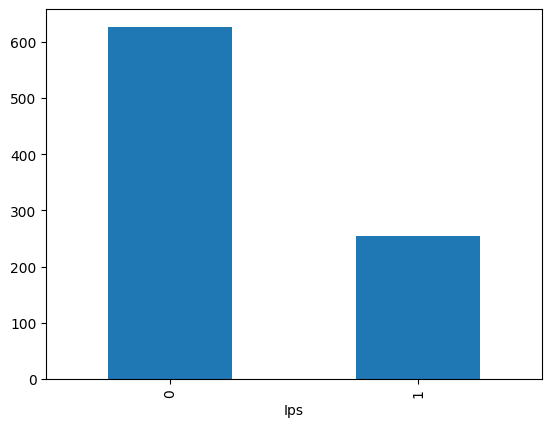

In [25]:
df['Ips'].value_counts().plot(kind='bar')

<Axes: xlabel='Ips', ylabel='Price (Euro)'>

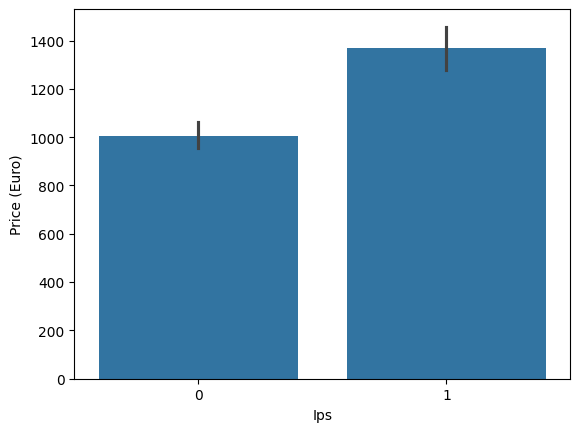

In [26]:
sns.barplot(x=df['Ips'],y=df['Price (Euro)'])

In [27]:
df[['X_res', 'Y_res']] = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(int)
df_test[['X_res', 'Y_res']] = df_test['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(int)

In [28]:
df.sample(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,X_res,Y_res
567,Fujitsu,Lifebook A557,Notebook,15.6,1366x768,Intel,Core i5 7200U,2.5,8,1TB HDD,Intel,HD Graphics 620,Windows 10,2.20,739.0,0,0,1366,768
359,Dell,Latitude 7480,Notebook,14.0,Full HD 1920x1080,Intel,Core i5 7300U,2.6,8,256GB SSD,Intel,HD Graphics 620,Windows 10,1.36,1427.0,0,0,1920,1080
561,Lenovo,V330-15IKB (i3-7130U/4GB/128GB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel,Core i3 7130U,2.7,4,128GB SSD,Intel,HD Graphics 620,Windows 10,2.05,630.0,0,0,1920,1080
420,Lenovo,Yoga 720-15IKB,2 in 1 Convertible,15.6,IPS Panel 4K Ultra HD / Touchscreen 3840x2160,Intel,Core i7 7700HQ,2.8,16,512GB SSD,Nvidia,GeForce GTX 1050,Windows 10,2.00,1899.0,1,1,3840,2160
180,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,256GB SSD + 2TB HDD,AMD,Radeon 530,Linux,2.02,1049.0,0,0,1920,1080
123,HP,Probook 470,Notebook,17.3,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce 930MX,Windows 10,2.50,1271.0,0,0,1920,1080
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.0,0,0,1366,768
165,MSI,GE63VR 7RE,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel,Core i7 7700HQ,2.8,16,256GB SSD + 1TB HDD,Nvidia,GeForce GTX 1060,Windows 10,2.40,1799.0,0,1,1920,1080
838,Lenovo,N42-20 Chromebook,Notebook,14.0,1366x768,Intel,Celeron Quad Core N3160,1.6,4,16GB Flash Storage,Intel,HD Graphics 400,Chrome OS,1.50,325.0,0,0,1366,768
315,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,128GB SSD + 1TB HDD,AMD,Radeon 530,Windows 10,2.33,844.0,0,0,1920,1080


In [29]:
df.sample(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,X_res,Y_res
877,Xiaomi,Mi Notebook,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel,Core i5 6200U,2.3,8,256GB SSD,Nvidia,GeForce 940MX,Windows 10,1.28,935.00,0,1,1920,1080
117,Dell,Inspiron 7570,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel,Core i7 8550U,1.8,8,256GB SSD + 1TB HDD,Nvidia,GeForce 940MX,Windows 10,2.16,1130.33,0,1,1920,1080
756,HP,15-cb003na (i5-7300HQ/8GB/1TB,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel,Core i5 7300HQ,2.5,8,128GB SSD + 1TB HDD,Nvidia,GeForce GTX 1050,Windows 10,2.20,1099.00,0,1,1920,1080
407,Dell,Latitude 7480,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 7600U,2.8,8,512GB SSD,Intel,HD Graphics,Windows 10,1.36,1680.00,0,0,1920,1080
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0,0,1440,900
46,Lenovo,IdeaPad 320-15ISK,Notebook,15.6,1366x768,Intel,Core i3 6006U,2.0,4,128GB SSD,Intel,HD Graphics 520,No OS,2.20,369.00,0,0,1366,768
246,HP,15-bs015dx (i5-7200U/8GB/1TB/W10),Notebook,15.6,Touchscreen 1366x768,Intel,Core i5 7200U,2.5,8,1TB HDD,Intel,HD Graphics 620,Windows 10,2.04,559.00,1,0,1366,768
796,Asus,R417NA-RS01 (N3350/4GB/32GB/W10),Notebook,14.0,1366x768,Intel,Celeron Dual Core N3350,1.1,4,32GB Flash Storage,Intel,HD Graphics 500,Windows 10,1.63,299.00,0,0,1366,768
571,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel,Pentium Quad Core N3710,1.6,8,2TB HDD,Intel,HD Graphics 405,Windows 10,1.94,389.00,0,0,1366,768
410,Lenovo,ThinkPad P51,Workstation,15.6,Full HD 1920x1080,Intel,Core i7 7700HQ,2.8,8,512GB SSD,Nvidia,Quadro M1200,Windows 10,2.67,1925.00,0,0,1920,1080


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    object 
 1   Product              881 non-null    object 
 2   TypeName             881 non-null    object 
 3   Inches               881 non-null    float64
 4   ScreenResolution     881 non-null    object 
 5   CPU_Company          881 non-null    object 
 6   CPU_Type             881 non-null    object 
 7   CPU_Frequency (GHz)  881 non-null    float64
 8   RAM (GB)             881 non-null    int64  
 9   Memory               881 non-null    object 
 10  GPU_Company          881 non-null    object 
 11  GPU_Type             881 non-null    object 
 12  OpSys                881 non-null    object 
 13  Weight (kg)          881 non-null    float64
 14  Price (Euro)         881 non-null    float64
 15  Touchscreen          881 non-null    int

In [31]:
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5/df['Inches']).astype('float')
df_test['ppi'] = (((df_test['X_res']**2) + (df_test['Y_res']**2))**0.5/df_test['Inches']).astype('float')

df['ppi']=df['ppi'].fillna(df['ppi'].mean())
df_test['ppi']=df_test['ppi'].fillna(df['ppi'].mean())

<Axes: xlabel='ppi', ylabel='Price (Euro)'>

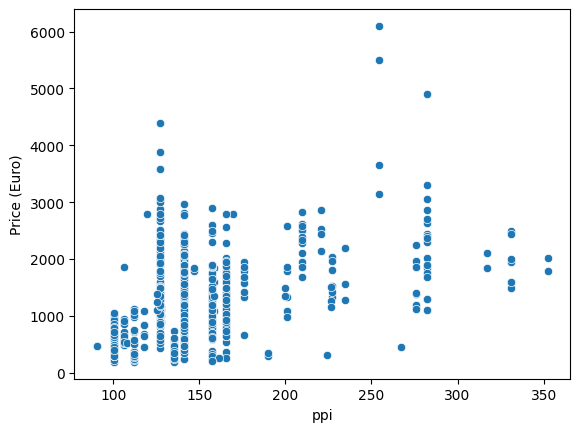

In [32]:
sns.scatterplot(x=df['ppi'],y=df['Price (Euro)'])

In [33]:
df['X_res'].sample(10)

4      2560
477    1920
376    1366
300    1366
567    1366
546    1920
56     1920
388    1920
799    1920
756    1920
Name: X_res, dtype: int64

In [34]:
df['X_res'].value_counts()

X_res
1920    597
1366    184
3840     33
2560     19
1600     16
3200      9
2256      6
2880      4
1440      4
2304      3
2400      3
2160      2
2736      1
Name: count, dtype: int64

In [35]:
df['Y_res'].value_counts()

Y_res
1080    595
768     184
2160     33
900      20
1440     18
1800     13
1600      9
1504      6
1200      2
1824      1
Name: count, dtype: int64

In [36]:
df.corr(numeric_only=True)['Price (Euro)']

Inches                 0.092347
CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
X_res                  0.574924
Y_res                  0.572712
ppi                    0.490622
Name: Price (Euro), dtype: float64

In [37]:
df.drop(columns=['ScreenResolution','Inches','X_res','Y_res'],inplace=True)
df_test.drop(columns=['ScreenResolution','Inches','X_res','Y_res'],inplace=True)

In [38]:
df.head()

,Company,Product,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi
0,Apple,MacBook Pro,Ultrabook,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005
1,Apple,Macbook Air,Ultrabook,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940
2,HP,250 G6,Notebook,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998
3,Apple,MacBook Pro,Ultrabook,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624
4,Apple,MacBook Pro,Ultrabook,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005


In [39]:
df.drop(columns=['Product'],inplace=True)
df_test.drop(columns=['Product'],inplace=True)

In [40]:
df['CPU_Company'].value_counts().head(50)

CPU_Company
Intel    835
AMD       46
Name: count, dtype: int64

In [41]:
df['CPU_Type'].value_counts().head(50)

CPU_Type
Core i5 7200U              134
Core i7 7700HQ             117
Core i7 7500U               91
Core i5 8250U               71
Core i7 8550U               71
Core i3 6006U               63
Core i5 7300HQ              28
Celeron Dual Core N3350     27
Core i3 7100U               24
Core i5 6200U               22
Celeron Dual Core N3060     17
Core i7 6500U               13
Core i7 7600U               12
Core i5 7300U               12
A9-Series 9420              11
Core i5                     11
Pentium Quad Core N4200     11
Core i7 6700HQ               9
Core i3 7130U                8
Core i7 7820HK               7
Pentium Quad Core N3710      6
A6-Series 9220               6
Atom x5-Z8350                5
Core i7 7820HQ               5
Celeron Quad Core N3450      5
Core i7 6600U                5
Core i7 6820HQ               4
Core i5 7440HQ               4
A12-Series 9720P             4
Core i7                      4
Core i7 6820HK               4
Celeron Dual Core 3855U      3

In [42]:
df['CPU'] = df['CPU_Type'].str.extract(r'(Core i[3579]|Core M|Ryzen|Xeon|Celeron|Pentium|Atom|A\d+-Series|E-Series|FX)')
df_test['CPU'] = df_test['CPU_Type'].str.extract(r'(Core i[3579]|Core M|Ryzen|Xeon|Celeron|Pentium|Atom|A\d+-Series|E-Series|FX)')

In [43]:
df['CPU'].value_counts().head(50)

CPU
Core i7       350
Core i5       292
Core i3        98
Celeron        57
Pentium        19
A9-Series      13
Atom            8
A6-Series       8
E-Series        7
Core M          7
A10-Series      6
A12-Series      5
Xeon            4
Ryzen           4
A8-Series       2
FX              1
Name: count, dtype: int64

<Axes: xlabel='CPU'>

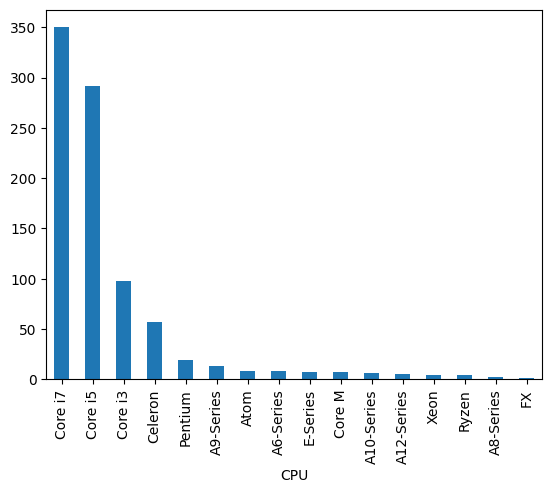

In [44]:
df['CPU'].value_counts().plot(kind='bar')

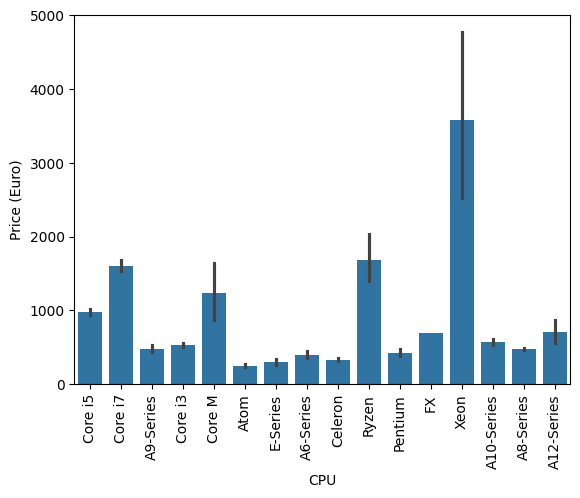

In [45]:
sns.barplot(x=df['CPU'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='RAM (GB)'>

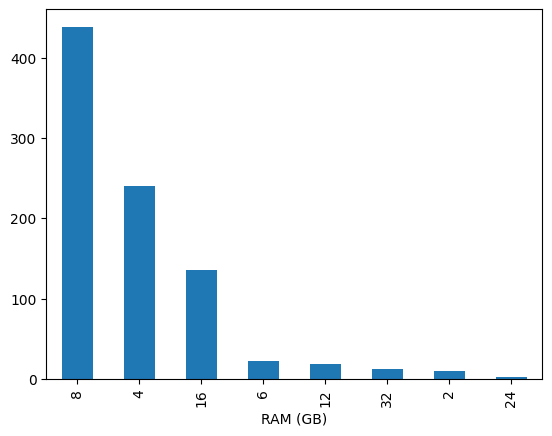

In [46]:
df['RAM (GB)'].value_counts().plot(kind='bar')

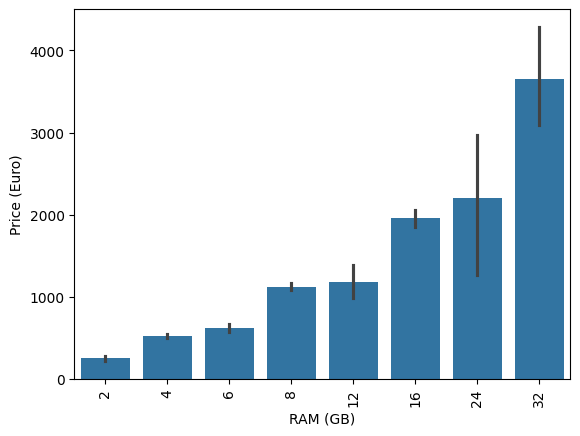

In [47]:
sns.barplot(x=df['RAM (GB)'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [48]:
df['Memory'].value_counts()

Memory
256GB SSD                        287
1TB HDD                          155
512GB SSD                         83
500GB HDD                         69
128GB SSD +  1TB HDD              63
128GB SSD                         59
256GB SSD +  1TB HDD              48
32GB Flash Storage                25
2TB HDD                           14
256GB SSD +  2TB HDD              10
512GB SSD +  1TB HDD              10
1TB SSD                           10
64GB Flash Storage                 8
32GB SSD                           5
16GB Flash Storage                 5
256GB Flash Storage                4
128GB Flash Storage                4
180GB SSD                          4
16GB SSD                           2
1TB SSD +  1TB HDD                 2
128GB SSD +  2TB HDD               2
1.0TB Hybrid                       1
64GB SSD                           1
256GB SSD +  256GB SSD             1
256GB SSD +  500GB HDD             1
512GB SSD +  256GB SSD             1
512GB SSD +  512GB SSD         

In [49]:
df['Memory'] = df['Memory'].astype(str).replace(r'\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')
new = df["Memory"].str.split("+", n = 1, expand = True)

df["first"]= new[0]
df["first"]=df["first"].str.strip()

df["second"]= new[1]

df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['first'] = df['first'].str.replace(r'\D', '', regex=True)

df["second"] = df["second"].fillna("0")

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [50]:
df_test['Memory'] = df_test['Memory'].astype(str).replace(r'\.0', '', regex=True)
df_test["Memory"] = df_test["Memory"].str.replace('GB', '')
df_test["Memory"] = df_test["Memory"].str.replace('TB', '000')
new_test = df_test["Memory"].str.split("+", n = 1, expand = True)

df_test["first"]= new_test[0]
df_test["first"]=df_test["first"].str.strip()

df_test["second"]= new_test[1]

df_test["Layer1HDD"] = df_test["first"].apply(lambda x: 1 if "HDD" in x else 0)
df_test["Layer1SSD"] = df_test["first"].apply(lambda x: 1 if "SSD" in x else 0)
df_test["Layer1Hybrid"] = df_test["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df_test["Layer1Flash_Storage"] = df_test["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df_test['first'] = df_test['first'].str.replace(r'\D', '', regex=True)

df_test["second"] = df_test["second"].fillna("0")

df_test["Layer2HDD"] = df_test["second"].apply(lambda x: 1 if "HDD" in x else 0)
df_test["Layer2SSD"] = df_test["second"].apply(lambda x: 1 if "SSD" in x else 0)
df_test["Layer2Hybrid"] = df_test["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df_test["Layer2Flash_Storage"] = df_test["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df_test['second'] = df_test['second'].str.replace(r'\D', '', regex=True)

df_test["first"] = df_test["first"].astype(int)
df_test["second"] = df_test["second"].astype(int)

df_test["HDD"]=(df_test["first"]*df_test["Layer1HDD"]+df_test["second"]*df_test["Layer2HDD"])
df_test["SSD"]=(df_test["first"]*df_test["Layer1SSD"]+df_test["second"]*df_test["Layer2SSD"])
df_test["Hybrid"]=(df_test["first"]*df_test["Layer1Hybrid"]+df_test["second"]*df_test["Layer2Hybrid"])
df_test["Flash_Storage"]=(df_test["first"]*df_test["Layer1Flash_Storage"]+df_test["second"]*df_test["Layer2Flash_Storage"])

df_test.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [51]:
df.head()

,Company,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,Intel,Core i5,2.3,8,128 SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005,Core i5,0,128,0,0
1,Apple,Ultrabook,Intel,Core i5,1.8,8,128 Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940,Core i5,0,0,0,128
2,HP,Notebook,Intel,Core i5 7200U,2.5,8,256 SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998,Core i5,0,256,0,0
3,Apple,Ultrabook,Intel,Core i7,2.7,16,512 SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624,Core i7,0,512,0,0
4,Apple,Ultrabook,Intel,Core i5,3.1,8,256 SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005,Core i5,0,256,0,0


In [52]:
df.drop(columns=['Memory'],inplace=True)
df_test.drop(columns=['Memory'],inplace=True)

In [53]:
df.corr(numeric_only=True)['Price (Euro)']

CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
ppi                    0.490622
HDD                   -0.084962
SSD                    0.677730
Hybrid                -0.010011
Flash_Storage         -0.045146
Name: Price (Euro), dtype: float64

In [54]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)
df_test.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [55]:
df['GPU_Type'].value_counts()

GPU_Type
HD Graphics 620       197
HD Graphics 520        83
UHD Graphics 620       66
GeForce GTX 1050       54
Radeon 530             37
                     ... 
Radeon R7 Graphics      1
GeForce 920             1
GeForce 940M            1
GeForce GTX 930MX       1
Radeon R7 M465          1
Name: count, Length: 92, dtype: int64

In [56]:
df['GPU_Company'].value_counts()

GPU_Company
Intel     464
Nvidia    283
AMD       134
Name: count, dtype: int64

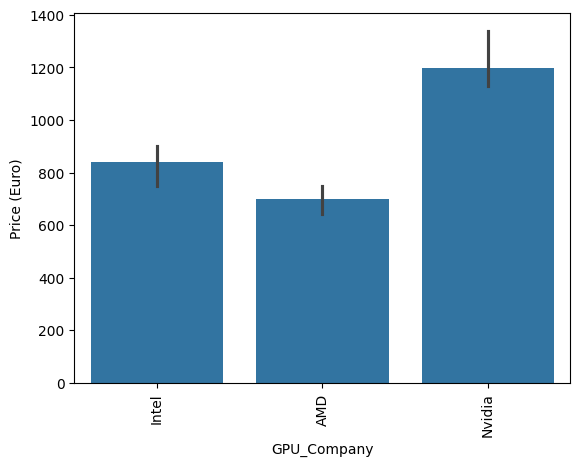

In [57]:
sns.barplot(x=df['GPU_Company'],y=df['Price (Euro)'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

In [58]:
df.drop(columns=['GPU_Type'],inplace=True)
df_test.drop(columns=['GPU_Type'],inplace=True)

In [59]:
df.drop(columns=['CPU_Type'],inplace=True)
df_test.drop(columns=['CPU_Type'],inplace=True)

In [60]:
df.sample(10)

,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD
659,Dell,Gaming,Intel,2.80,32,Nvidia,Windows 10,4.42,3147.37,0,1,254.671349,Core i7,1000,512
152,Lenovo,Notebook,Intel,2.50,4,Intel,Windows 10,1.90,498.00,0,0,100.454670,Core i5,0,128
741,Dell,Notebook,Intel,2.00,8,Intel,Windows 10,2.00,665.00,0,0,100.454670,Core i3,0,256
275,Dell,Notebook,Intel,2.70,12,Intel,Windows 10,2.30,713.07,0,0,100.454670,Core i7,1000,0
377,Dell,Notebook,Intel,1.60,4,Intel,Windows 10,1.80,309.00,0,0,100.454670,Celeron,500,0
626,Mediacom,Notebook,Intel,1.44,2,Intel,Windows 10,1.40,239.00,0,0,157.350512,Atom,0,0
747,HP,Notebook,Intel,2.00,8,Intel,Windows 10,1.86,539.00,0,0,141.211998,Core i3,0,256
822,Lenovo,Ultrabook,Intel,2.70,8,Intel,Windows 10,1.13,2499.00,0,1,157.350512,Core i7,0,512
544,Asus,Notebook,AMD,1.80,4,AMD,Windows 10,2.00,349.00,0,0,100.454670,E-Series,500,0
564,Asus,Notebook,Intel,2.50,8,Nvidia,Windows 10,2.50,839.00,0,0,141.211998,Core i5,1000,128


In [61]:
df['TypeName'].value_counts()

TypeName
Notebook              503
Gaming                135
Ultrabook             134
2 in 1 Convertible     72
Workstation            23
Netbook                14
Name: count, dtype: int64

In [62]:
df['OpSys'].value_counts()

OpSys
Windows 10      735
No OS            50
Linux            45
Chrome OS        17
macOS            13
Windows 7         8
Windows 10 S      8
Mac OS X          4
Android           1
Name: count, dtype: int64

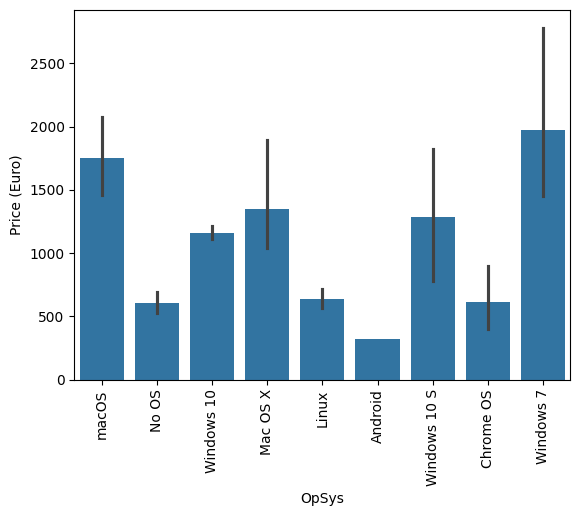

In [63]:
sns.barplot(x=df['OpSys'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [64]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Other'

In [65]:
df['OS'] = df['OpSys'].apply(cat_os)
df_test['OS'] = df_test['OpSys'].apply(cat_os)

In [66]:
df.head()

,Company,TypeName,CPU_Company,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,HDD,SSD,OS
0,Apple,Ultrabook,Intel,2.3,8,Intel,macOS,1.37,1339.69,0,1,226.983005,Core i5,0,128,Mac
1,Apple,Ultrabook,Intel,1.8,8,Intel,macOS,1.34,898.94,0,0,127.677940,Core i5,0,0,Mac
2,HP,Notebook,Intel,2.5,8,Intel,No OS,1.86,575.00,0,0,141.211998,Core i5,0,256,Other
3,Apple,Ultrabook,Intel,2.7,16,AMD,macOS,1.83,2537.45,0,1,220.534624,Core i7,0,512,Mac
4,Apple,Ultrabook,Intel,3.1,8,Intel,macOS,1.37,1803.60,0,1,226.983005,Core i5,0,256,Mac


In [67]:
df.drop(columns=['OpSys'],inplace=True)
df_test.drop(columns=['OpSys'],inplace=True)

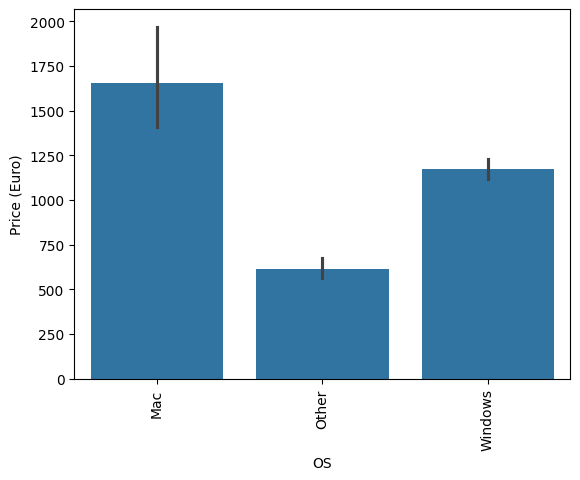

In [68]:
sns.barplot(x=df['OS'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

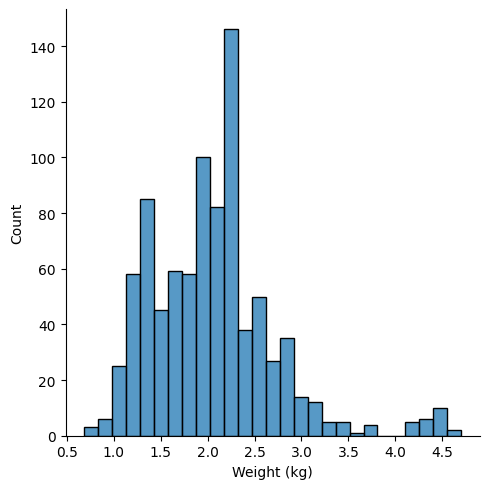

In [69]:
sns.displot(df['Weight (kg)'])

<Axes: xlabel='Weight (kg)', ylabel='Price (Euro)'>

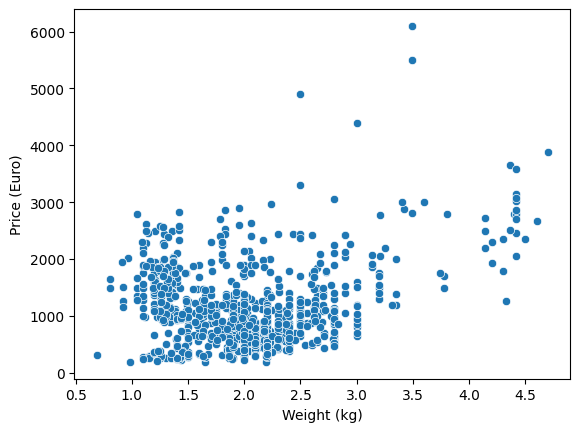

In [70]:
sns.scatterplot(x=df['Weight (kg)'],y=df['Price (Euro)'])

In [71]:
df.corr(numeric_only=True)['Price (Euro)']

CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
ppi                    0.490622
HDD                   -0.084962
SSD                    0.677730
Name: Price (Euro), dtype: float64

# **EDA**

<Axes: >

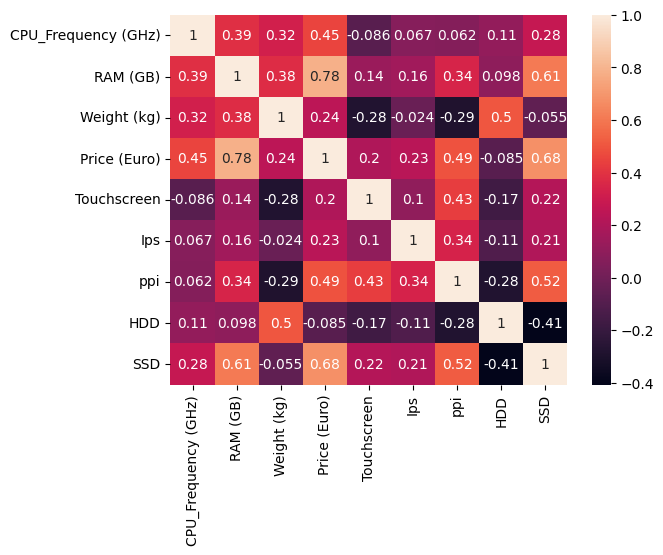

In [72]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

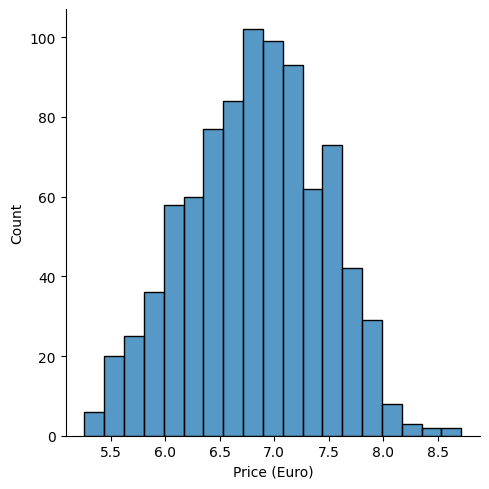

In [73]:
sns.displot(np.log(df['Price (Euro)']))

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    object 
 1   TypeName             881 non-null    object 
 2   CPU_Company          881 non-null    object 
 3   CPU_Frequency (GHz)  881 non-null    float64
 4   RAM (GB)             881 non-null    int64  
 5   GPU_Company          881 non-null    object 
 6   Weight (kg)          881 non-null    float64
 7   Price (Euro)         881 non-null    float64
 8   Touchscreen          881 non-null    int64  
 9   Ips                  881 non-null    int64  
 10  ppi                  881 non-null    float64
 11  CPU                  881 non-null    object 
 12  HDD                  881 non-null    int64  
 13  SSD                  881 non-null    int64  
 14  OS                   881 non-null    object 
dtypes: float64(4), int64(5), object(6)
memor

In [75]:
df['Company'].value_counts()

Company
Lenovo       207
Dell         205
HP           157
Asus         116
Acer          76
Toshiba       31
MSI           30
Apple         17
Mediacom       7
Samsung        7
Microsoft      6
Razer          5
Xiaomi         4
Google         3
Chuwi          3
Huawei         2
Vero           2
Fujitsu        2
LG             1
Name: count, dtype: int64

# **Encoding**

In [76]:
df.nunique(np.dtype==object)

Company                 19
TypeName                 6
CPU_Company              2
CPU_Frequency (GHz)     25
RAM (GB)                 8
GPU_Company              3
Weight (kg)            157
Price (Euro)           590
Touchscreen              2
Ips                      2
ppi                     35
CPU                     16
HDD                      6
SSD                     11
OS                       3
dtype: int64

In [77]:
df = pd.get_dummies(df, columns=['Company','TypeName','CPU_Company','GPU_Company','CPU','OS'], drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Company','TypeName','CPU_Company','GPU_Company','CPU','OS'], drop_first=True)

In [78]:
df.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,CPU_Ryzen,CPU_Xeon,OS_Other,OS_Windows
0,2.3,8,1.37,1339.69,0,1,226.983005,0,128,True,...,False,True,False,False,False,False,False,False,False,False
1,1.8,8,1.34,898.94,0,0,127.677940,0,0,True,...,False,True,False,False,False,False,False,False,False,False
2,2.5,8,1.86,575.00,0,0,141.211998,0,256,False,...,False,True,False,False,False,False,False,False,True,False
3,2.7,16,1.83,2537.45,0,1,220.534624,0,512,True,...,False,False,True,False,False,False,False,False,False,False
4,3.1,8,1.37,1803.60,0,1,226.983005,0,256,True,...,False,True,False,False,False,False,False,False,False,False


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CPU_Frequency (GHz)   881 non-null    float64
 1   RAM (GB)              881 non-null    int64  
 2   Weight (kg)           881 non-null    float64
 3   Price (Euro)          881 non-null    float64
 4   Touchscreen           881 non-null    int64  
 5   Ips                   881 non-null    int64  
 6   ppi                   881 non-null    float64
 7   HDD                   881 non-null    int64  
 8   SSD                   881 non-null    int64  
 9   Company_Apple         881 non-null    bool   
 10  Company_Asus          881 non-null    bool   
 11  Company_Chuwi         881 non-null    bool   
 12  Company_Dell          881 non-null    bool   
 13  Company_Fujitsu       881 non-null    bool   
 14  Company_Google        881 non-null    bool   
 15  Company_HP            8

In [80]:
df_test.head()

,id,CPU_Frequency (GHz),RAM (GB),Weight (kg),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,CPU_Celeron,CPU_Core M,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,OS_Other,OS_Windows
0,882,2.5,4,2.30,1,0,100.454670,500,0,False,...,False,False,False,True,False,False,False,False,False,True
1,883,1.1,4,1.65,0,0,111.141337,0,0,False,...,True,False,False,False,False,False,False,False,False,True
2,884,2.5,8,2.20,0,1,141.211998,1000,0,False,...,False,False,False,False,True,False,False,False,False,True
3,885,1.6,4,2.20,0,0,100.454670,500,0,False,...,False,False,False,False,False,False,False,True,False,True
4,886,2.5,4,1.28,1,0,165.632118,0,256,False,...,False,False,False,True,False,False,False,False,False,True


In [81]:
df_test.shape

(394, 46)

In [82]:
df.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,CPU_Ryzen,CPU_Xeon,OS_Other,OS_Windows
0,2.3,8,1.37,1339.69,0,1,226.983005,0,128,True,...,False,True,False,False,False,False,False,False,False,False
1,1.8,8,1.34,898.94,0,0,127.677940,0,0,True,...,False,True,False,False,False,False,False,False,False,False
2,2.5,8,1.86,575.00,0,0,141.211998,0,256,False,...,False,True,False,False,False,False,False,False,True,False
3,2.7,16,1.83,2537.45,0,1,220.534624,0,512,True,...,False,False,True,False,False,False,False,False,False,False
4,3.1,8,1.37,1803.60,0,1,226.983005,0,256,True,...,False,True,False,False,False,False,False,False,False,False


# **Prepping Test Data**

In [84]:
X=df.drop(columns=['Price (Euro)'])
y=np.log(df['Price (Euro)'])

In [85]:
df_test.head()

,id,CPU_Frequency (GHz),RAM (GB),Weight (kg),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,CPU_Celeron,CPU_Core M,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,OS_Other,OS_Windows
0,882,2.5,4,2.30,1,0,100.454670,500,0,False,...,False,False,False,True,False,False,False,False,False,True
1,883,1.1,4,1.65,0,0,111.141337,0,0,False,...,True,False,False,False,False,False,False,False,False,True
2,884,2.5,8,2.20,0,1,141.211998,1000,0,False,...,False,False,False,False,True,False,False,False,False,True
3,885,1.6,4,2.20,0,0,100.454670,500,0,False,...,False,False,False,False,False,False,False,True,False,True
4,886,2.5,4,1.28,1,0,165.632118,0,256,False,...,False,False,False,True,False,False,False,False,False,True


In [86]:
missing_cols = set(X.columns) - set(df_test.columns)
for c in missing_cols:
    df_test[c] = False

extra_cols = set(df_test.columns) - set(X.columns) - {'id'}
df_test = df_test.drop(columns=list(extra_cols))

X_test=df_test[X.columns]

In [87]:
df_test.head()

,id,CPU_Frequency (GHz),RAM (GB),Weight (kg),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,...,OS_Windows,Company_Mediacom,Company_Huawei,CPU_Ryzen,CPU_Xeon,Company_Microsoft,Company_Google,CPU_A12-Series,Company_Xiaomi,Company_Chuwi
0,882,2.5,4,2.30,1,0,100.454670,500,0,False,...,True,False,False,False,False,False,False,False,False,False
1,883,1.1,4,1.65,0,0,111.141337,0,0,False,...,True,False,False,False,False,False,False,False,False,False
2,884,2.5,8,2.20,0,1,141.211998,1000,0,False,...,True,False,False,False,False,False,False,False,False,False
3,885,1.6,4,2.20,0,0,100.454670,500,0,False,...,True,False,False,False,False,False,False,False,False,False
4,886,2.5,4,1.28,1,0,165.632118,0,256,False,...,True,False,False,False,False,False,False,False,False,False


In [88]:
X_test.head()

,CPU_Frequency (GHz),RAM (GB),Weight (kg),Touchscreen,Ips,ppi,HDD,SSD,Company_Apple,Company_Asus,...,CPU_Core i3,CPU_Core i5,CPU_Core i7,CPU_E-Series,CPU_FX,CPU_Pentium,CPU_Ryzen,CPU_Xeon,OS_Other,OS_Windows
0,2.5,4,2.30,1,0,100.454670,500,0,False,False,...,False,True,False,False,False,False,False,False,False,True
1,1.1,4,1.65,0,0,111.141337,0,0,False,True,...,False,False,False,False,False,False,False,False,False,True
2,2.5,8,2.20,0,1,141.211998,1000,0,False,False,...,False,False,True,False,False,False,False,False,False,True
3,1.6,4,2.20,0,0,100.454670,500,0,False,False,...,False,False,False,False,False,True,False,False,False,True
4,2.5,4,1.28,1,0,165.632118,0,256,False,False,...,False,True,False,False,False,False,False,False,False,True


# **Model Implementation**

### **Linear Regression**

In [89]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

r2 = cross_val_score(model, X, y, cv=kfold, scoring="r2")

mse = -cross_val_score(model, X, y, cv=kfold, scoring="neg_mean_squared_error")

mae = -cross_val_score(model, X, y, cv=kfold, scoring="neg_mean_absolute_error")

In [90]:
print("R2 per fold:", r2)
print("Mean R2:", r2.mean())
print("MSE per fold:", mse)
print("Mean MSE:", mse.mean())
print("MAE per fold:", mae)
print("Mean MAE:", mae.mean())

R2 per fold: [0.86835588 0.86138074 0.87053031 0.86368265 0.86134043]
Mean R2: 0.8650580029574808
MSE per fold: [0.05729274 0.04676865 0.04722607 0.05523638 0.05215601]
Mean MSE: 0.05173597181222398
MAE per fold: [0.19011635 0.17116908 0.17121894 0.18919177 0.18012053]
Mean MAE: 0.18036333380394381


### **Polynomial Regression**

In [91]:
num_features = ["CPU_Frequency (GHz)", "RAM (GB)", "Weight (kg)", "ppi", "HDD", "SSD"]
cat_features = [c for c in X.columns if c not in num_features]

degrees = [2,3,4,5]
for d in degrees:
    preprocess = ColumnTransformer(
    transformers=[
        ("num_poly", Pipeline([
        ("scale", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=True)),]), num_features),
        ("cat", "passthrough", cat_features),])

    model = Pipeline([
    ("pre", preprocess),
    ("reg", LinearRegression())
    ])
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")
    print(f"Degree {d}")
    print("R2 per fold:", scores)
    print("Mean R2:", scores.mean())
    print("======================")


Degree 2
R2 per fold: [0.87554493 0.86002255 0.87124488 0.87476412 0.85916173]
Mean R2: 0.8681476422155787
Degree 3
R2 per fold: [0.88028225 0.85179944 0.85017147 0.87210554 0.8593986 ]
Mean R2: 0.8627514589404608
Degree 4
R2 per fold: [0.84607458 0.82208189 0.84651511 0.55426608 0.85830193]
Mean R2: 0.7854479190576782
Degree 5
R2 per fold: [  0.85016115   0.81163025   0.79027924 -20.35851794   0.85998772]
Mean R2: -3.4092919142756495


### **Ridge Regression**

In [92]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

ridge = Ridge(alpha=0.1)

r2 = cross_val_score(ridge, X, y, cv=kfold, scoring="r2")
mse = -cross_val_score(ridge, X, y, cv=kfold, scoring="neg_mean_squared_error")
mae = -cross_val_score(ridge, X, y, cv=kfold, scoring="neg_mean_absolute_error")

print("R2 per fold:", r2)
print("Mean R2:", r2.mean())

print("MSE per fold:", mse)
print("Mean MSE:", mse.mean())

print("MAE per fold:", mae)
print("Mean MAE:", mae.mean())

R2 per fold: [0.86932883 0.86232541 0.87089603 0.86378474 0.86098079]
Mean R2: 0.8654631595466394
MSE per fold: [0.05686931 0.04644993 0.04709267 0.05519501 0.05229129]
Mean MSE: 0.05157964213690638
MAE per fold: [0.18950993 0.1703113  0.17038504 0.18869944 0.18058504]
Mean MAE: 0.17989814868321125


### **Lasso Regression**

In [93]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

lasso = Lasso(alpha=0.0001, max_iter=10000)

r2= cross_val_score(lasso, X, y, cv=kfold, scoring="r2")
mse = -cross_val_score(lasso, X, y, cv=kfold, scoring="neg_mean_squared_error")
mae = -cross_val_score(lasso, X, y, cv=kfold, scoring="neg_mean_absolute_error")

print("R2 per fold:", r2)
print("Mean R2:", r2.mean())

print("MSE per fold:", mse)
print("Mean MSE:", mse.mean())

print("MAE per fold:", mae)
print("Mean MAE:", mae.mean())

R2 per fold: [0.86972898 0.86266585 0.87047965 0.86354682 0.86025339]
Mean R2: 0.8653349409030465
MSE per fold: [0.05669516 0.04633506 0.04724455 0.05529142 0.0525649 ]
Mean MSE: 0.05162621784081216
MAE per fold: [0.18931299 0.16972663 0.17001404 0.18919712 0.18107062]
Mean MAE: 0.17986428248241307


### **Elastic Net Regression (EXTRA)** 

In [94]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

net = ElasticNet(alpha=0.0001, l1_ratio=0.3, max_iter=20000)

r2= cross_val_score(net, X, y, cv=kfold, scoring="r2")
mse = -cross_val_score(net, X, y, cv=kfold, scoring="neg_mean_squared_error")
mae = -cross_val_score(net, X, y, cv=kfold, scoring="neg_mean_absolute_error")

print("R2 per fold:", r2)
print("Mean R2:", r2.mean())

print("MSE per fold:", mse)
print("Mean MSE:", mse.mean())

print("MAE per fold:", mae)
print("Mean MAE:", mae.mean())

R2 per fold: [0.86928702 0.86230614 0.87074939 0.86369817 0.86094527]
Mean R2: 0.8653971973366387
MSE per fold: [0.0568875  0.04645643 0.04714616 0.05523009 0.05230465]
Mean MSE: 0.05160496735597257
MAE per fold: [0.18958356 0.17031901 0.17040872 0.18896249 0.18059339]
Mean MAE: 0.17997343383602998


### **Regression Trees**

In [95]:
num_features = ["CPU_Frequency (GHz)", "RAM (GB)", "Weight (kg)", "ppi", "HDD", "SSD"]
cat_features = [c for c in X.columns if c not in num_features]

depths = [2,3,4,5,6]

for d in depths:

    preprocess = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_features),
            ("cat", "passthrough", cat_features)
        ]
    )

    model = Pipeline([
        ("pre", preprocess),
        ("reg", DecisionTreeRegressor(max_depth=d, random_state=42))
    ])

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")

    print(f"Tree Depth {d}")
    print("R2 per fold:", scores)
    print("Mean R2:", scores.mean())
    print("======================")

Tree Depth 2
R2 per fold: [0.64914001 0.6111741  0.6362102  0.65906663 0.68224425]
Mean R2: 0.6475670365924355
Tree Depth 3
R2 per fold: [0.71457971 0.69969013 0.71800786 0.73423092 0.73071295]
Mean R2: 0.7194443152813219
Tree Depth 4
R2 per fold: [0.75116372 0.72560727 0.78323484 0.76100051 0.77004607]
Mean R2: 0.7582104821827785
Tree Depth 5
R2 per fold: [0.79466862 0.70515952 0.78952351 0.78514728 0.78860016]
Mean R2: 0.7726198175172506
Tree Depth 6
R2 per fold: [0.79906862 0.72422657 0.82975431 0.80559529 0.79048735]
Mean R2: 0.7898264290368447


### **Best Model Fine-Tuning (Ridge)**

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=20000))
])

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions={"lasso__alpha": loguniform(1e-5, 1e1)},
    n_iter=20,
    cv=kfold,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

rs.fit(X, y)

print("Best alpha:", rs.best_params_["lasso__alpha"])
print("Best CV R2:", rs.best_score_)
best_model = rs.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best alpha: 0.0006690421166498799
Best CV R2: 0.8652531218852737


### **Learnig Curve**

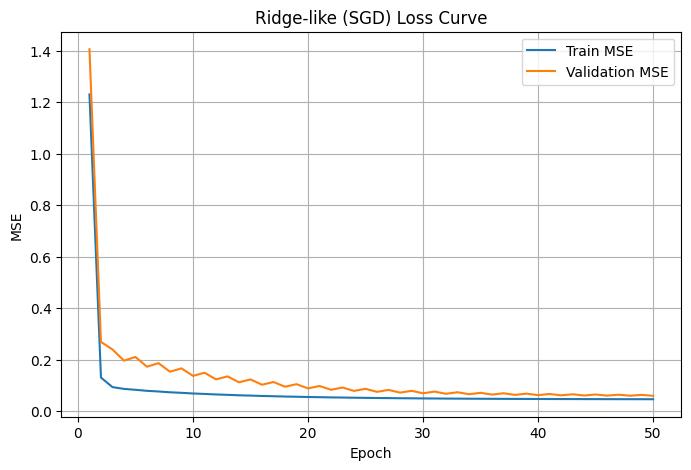

In [97]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

epochs = 50

model = Pipeline([
    ("scaler", StandardScaler()),
    ("sgd", SGDRegressor(
        loss="squared_error",
        penalty="l2",      
        alpha=1e-4,          
        learning_rate="invscaling",
        eta0=0.01,
        power_t=0.25,
        max_iter=1,          
        tol=None,
        random_state=42,
        warm_start=True,
        fit_intercept=True,
        average=False
    ))
])

train_mse, val_mse = [], []

for epoch in range(1, epochs + 1):
    model.fit(X_train, y_train)  
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    train_mse.append(mean_squared_error(y_train, train_pred))
    val_mse.append(mean_squared_error(y_val, val_pred))

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_mse, label="Train MSE")
plt.plot(range(1, epochs+1), val_mse, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Ridge-like (SGD) Loss Curve")
plt.grid(True)
plt.legend()
plt.show()